# HIDS Anomaly Detection Training
Train Isolation Forest model on NSL-KDD dataset

In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Dataset

In [8]:
# Column names for NSL-KDD
columns = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
           'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
           'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
           'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
           'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
           'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
           'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
           'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
           'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
           'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty']

# Load training data
train_df = pd.read_csv('/home/jovyan/datasets/KDDTrain+.txt', names=columns)
test_df = pd.read_csv('/home/jovyan/datasets/KDDTest+.txt', names=columns)

print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print(f"\nLabel distribution:\n{train_df['label'].value_counts()}")

Training samples: 62478
Test samples: 22544

Label distribution:
label
normal             33191
neptune            20570
satan               1813
ipsweep             1798
portsweep           1478
smurf               1313
nmap                 740
back                 497
warezclient          465
teardrop             436
pod                   86
guess_passwd          26
buffer_overflow       17
warezmaster           13
rootkit                7
imap                   6
multihop               5
land                   5
ftp_write              4
phf                    3
loadmodule             3
spy                    1
Name: count, dtype: int64


## 2. Preprocess Data

In [3]:
# Binary classification: normal vs attack
train_df['is_attack'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['is_attack'] = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Select features (numeric only for simplicity)
feature_cols = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count',
                'serror_rate', 'srv_serror_rate', 'same_srv_rate']

X_train = train_df[feature_cols]
y_train = train_df['is_attack']

X_test = test_df[feature_cols]
y_test = test_df['is_attack']

print(f"Features: {feature_cols}")
print(f"Training shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Features: ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'same_srv_rate']
Training shape: (62478, 8)
Test shape: (22544, 8)


## 3. Train Isolation Forest

In [4]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model (use only normal traffic)
X_train_normal = X_train_scaled[y_train == 0]
print(f"Training on {len(X_train_normal)} normal samples...")

model = IsolationForest(
    contamination=0.1,
    random_state=42,
    n_estimators=100,
    max_samples='auto',
    verbose=1
)

model.fit(X_train_normal)
print("Training complete!")

Training on 33191 normal samples...


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s


Training complete!


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.3s finished


## 4. Evaluate Model

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.3s finished


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.91      0.75      9711
           1       0.90      0.60      0.72     12833

    accuracy                           0.73     22544
   macro avg       0.77      0.75      0.73     22544
weighted avg       0.78      0.73      0.73     22544



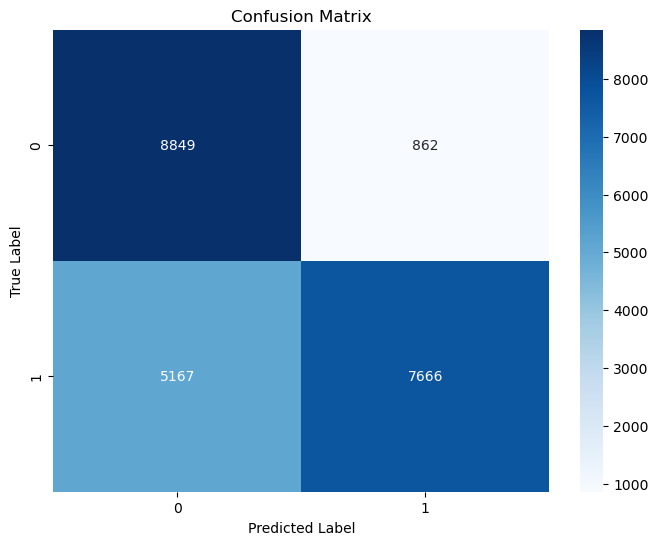

In [5]:
# Predict on test set
y_pred = model.predict(X_test_scaled)
y_pred_binary = (y_pred == -1).astype(int)  # -1 = anomaly, 1 = normal

# Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred_binary))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 5. Save Model

In [6]:
# Save to shared models directory
import os
os.makedirs('/home/jovyan/work/../models', exist_ok=True)

joblib.dump(model, '/home/jovyan/work/../models/anomaly_detector.pkl')
joblib.dump(scaler, '/home/jovyan/work/../models/scaler.pkl')

print("Model saved to /models/")
print("Copy to ML service: docker cp hids_jupyter:/home/jovyan/models/. ./hids/models/")

Model saved to /models/
Copy to ML service: docker cp hids_jupyter:/home/jovyan/models/. ./hids/models/
